#Capstone 2
Nama    : Starletto Abadi


Dataset : California Housing Price


Goal : Mengidentifikasi harga rumah di California




##Penjelasan

####Pengguna model : Pemilik properti rumah California yang menggunakan model akan mengetahui berapa perkiraan harga rumah yang dimilikinya


- Who : Pemilik rumah California
- What : Pemilik rumah kesulitan untuk menentukan estimasi harga rumah pada lokasi tertentu
- Why : Pemilik rumah akan merugi jika harga rumah yang dimiliki tidak sesuai dan akan menyebabkan kesulitan untuk berkompetitif di lokasi tertentu
- Target : Estimasi harga rumah berdasarkan data California Housing Price yang dimiliki menggunakan model Machine Learning (Regression)


####Evaluasi Metrik yang digunakan:
- MAE (Mean Absolute Error) : Rata-rata absolut kesalahan prediksi.
- MSE (Mean Squared Error) : Rata-rata kuadrat kesalahan prediksi, menghitung seberapa besar error varians.
- RMSE (Root Mean Squared Error) : Akar MSE, untuk menghukum lebih berat kesalahan prediksi.
- MAPE (Mean Absolute Percentage Error) : Presentasi rata-rata kesalahan. (Contoh: "Rata-rata meleset: 10%")
- MPSE (Mean Percentage Squared Error) : Kuadrat dari presentase kesalahan, untuk menghukum presentasi yang lebih besar.
- MSLE (Mean Squared Logarithmic Error) : Mengukur perbedaan logaritma antar prediksi dan nilai sebenarnya. (Untuk menghindari bias dengan rumah yang lebih mahal)
- R-Squared : Besaran variasi data target yang dijelaskan model dengan range 0-1.

In [3]:
#Import library yang digunakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_squared_log_error,
    mean_absolute_percentage_error
)

In [6]:
#Import data csv
df = pd.read_csv("data_california_house.csv")

#Melihat informasi data
df.info()
print()
print()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14448 entries, 0 to 14447
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           14448 non-null  float64
 1   latitude            14448 non-null  float64
 2   housing_median_age  14448 non-null  float64
 3   total_rooms         14448 non-null  float64
 4   total_bedrooms      14311 non-null  float64
 5   population          14448 non-null  float64
 6   households          14448 non-null  float64
 7   median_income       14448 non-null  float64
 8   ocean_proximity     14448 non-null  object 
 9   median_house_value  14448 non-null  float64
dtypes: float64(9), object(1)
memory usage: 1.1+ MB




,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-119.79,36.73,52.0,112.0,28.0,193.0,40.0,1.9750,INLAND,47500.0
1,-122.21,37.77,43.0,1017.0,328.0,836.0,277.0,2.2604,NEAR BAY,100000.0
2,-118.04,33.87,17.0,2358.0,396.0,1387.0,364.0,6.2990,<1H OCEAN,285800.0
3,-118.28,34.06,17.0,2518.0,1196.0,3051.0,1000.0,1.7199,<1H OCEAN,175000.0
4,-119.81,36.73,50.0,772.0,194.0,606.0,167.0,2.2206,INLAND,59200.0


##Penjelasan Kolom
- longitude & latitude : Lokasi
- housing median age : Median dari umur berbagai rumah
- total rooms : Total ruangan dari berbagai rumah
- total bedroom : Total kamar tidur dari berbagai rumah
- population : Total populasi dari lokasi
- households : Total keluarga yang tinggal di lokasi
- median income : Median dari pendapatan orang-orang yang ada di lokasi
- ocean proximity : Kedekatan lokasi dengan laut
- median house value : Median harga rumah dari lokasi

In [7]:
#Melihat statistik dasar data
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,14448.000000,14448.000000,14448.000000,14448.000000,14311.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,-119.566647,35.630093,28.618702,2640.132683,538.260709,1425.157323,499.508929,3.866667,206824.624516
std,2.006587,2.140121,12.596694,2191.612441,423.577544,1149.580157,383.098390,1.891158,115365.476182
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1451.000000,295.000000,784.000000,279.000000,2.570600,119600.000000
50%,-118.490000,34.260000,29.000000,2125.000000,435.000000,1165.000000,410.000000,3.539100,180000.000000
75%,-118.000000,37.710000,37.000000,3148.000000,647.000000,1724.000000,604.000000,4.736100,263900.000000
max,-114.310000,41.950000,52.000000,32627.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


##EDA
- Distribusi data dari target
- Distribusi data dari kolom yang memiliki missing value
- Correlation heatmap untuk melihat korelasi antar kolom numerik yang ada

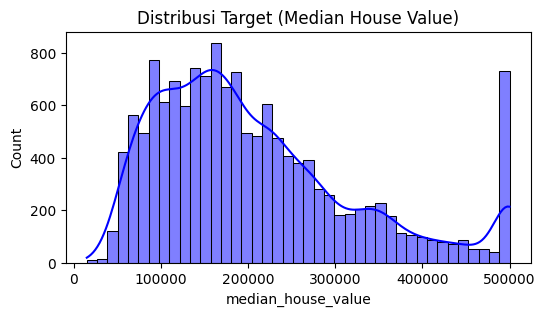

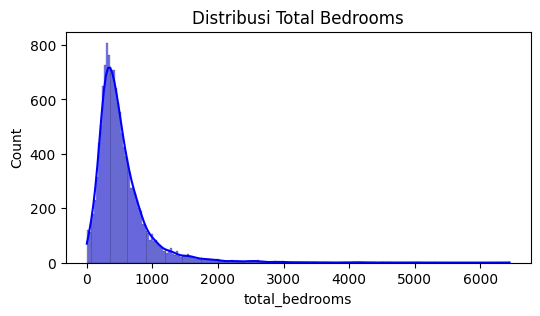

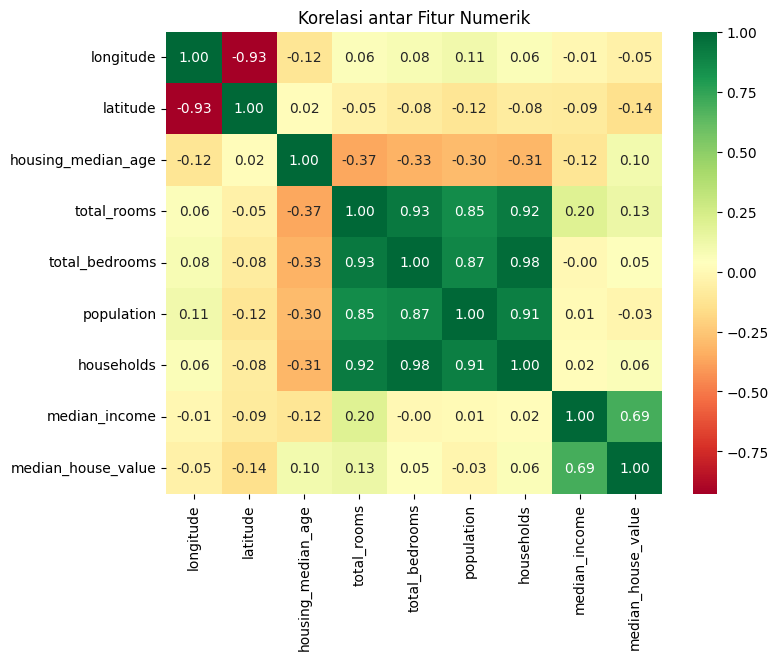

In [8]:
##EDA singkat
# Visualisasi Target
plt.figure(figsize=(6, 3))
sns.histplot(df['median_house_value'], kde=True, color='blue')
plt.title('Distribusi Target (Median House Value)')
plt.show()
print()

plt.figure(figsize=(6, 3))
sns.histplot(df['total_bedrooms'], kde=True, color='blue')
plt.title('Distribusi Total Bedrooms')
plt.show()
print()

# Korelasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Korelasi antar Fitur Numerik')
plt.show()


Median house value yang menjadi target memiliki korelasi positif yang sangat tinggi dengan median income, Ini berarti semakin tinggi pendapatan di suatu lokasi, maka harga rumah di sana akan semakin tinggi juga

##Data cleaning

In [90]:
df_model = df.copy()

In [21]:
# Cek data duplikat
print(df_model.duplicated().sum())

0


In [22]:
#Cek data hilang
print(df_model.isna().sum())

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        137
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64


Hanya kolom total_bedrooms yang memiliki missing value, dan akan didrop karena total_rooms telah cukup untuk merepresentasikan jumlah ruangan yang ada.
Kolom ouseholds juga akan didrop karena population telah cukup untuk merepresentasikan jumlah rumah tangga yang ada

In [91]:
df_model = df_model.drop('total_bedrooms', axis=1)
df_model = df_model.drop('households', axis=1)

<Axes: >

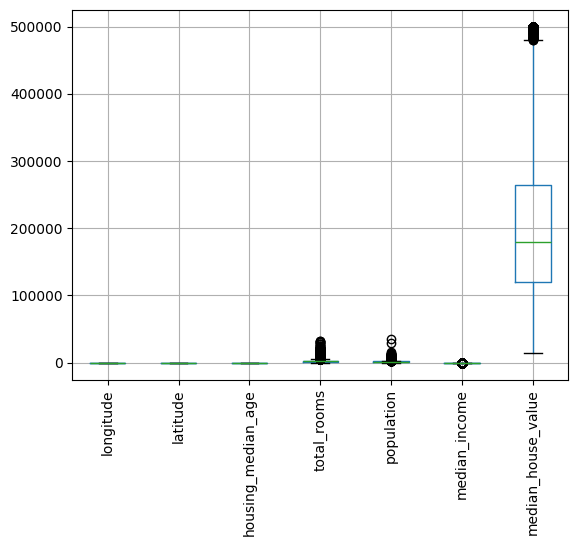

In [92]:
# Plot boxplot untuk mengecek outliers
df_model.boxplot(rot=90)

Terlihat outliers pada beberapa fitur dan data akan direkayasa sehingga model tidak akan memprediksi data 'bias'

In [79]:
# Membuat fungsi untuk mengecek outliers
def find_anomalies(data):
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    limit = iqr*1.5
    print(f'IQR: {iqr}')

    limit_bawah = q1 - limit
    limit_atas = q3 + limit
    print(f'limit_bawah: {limit_bawah}')
    print(f'limit_atas: {limit_atas}')

In [93]:
# Outliers pada fitur
print('Outliers pada fitur Total Rooms')
find_anomalies(df_model['total_rooms'])
print()
print('Outliers pada fitur Population')
find_anomalies(df_model['population'])
print()
print('Outliers pada fitur Median Income')
find_anomalies(df_model['median_income'])
print()
print('Outliers pada fitur Median House Value')
find_anomalies(df_model['median_house_value'])

Outliers pada fitur Total Rooms
IQR: 1697.0
limit_bawah: -1094.5
limit_atas: 5693.5

Outliers pada fitur Population
IQR: 940.0
limit_bawah: -626.0
limit_atas: 3134.0

Outliers pada fitur Median Income
IQR: 2.1655000000000006
limit_bawah: -0.6776500000000012
limit_atas: 7.984350000000001

Outliers pada fitur Median House Value
IQR: 144300.0
limit_bawah: -96850.0
limit_atas: 480350.0


In [41]:
df_model.describe()

,longitude,latitude,housing_median_age,total_rooms,population,median_income,median_house_value
count,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000,14448.000000
mean,-119.566647,35.630093,28.618702,2640.132683,1425.157323,3.866667,206824.624516
std,2.006587,2.140121,12.596694,2191.612441,1149.580157,1.891158,115365.476182
min,-124.350000,32.540000,1.000000,2.000000,3.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1451.000000,784.000000,2.570600,119600.000000
50%,-118.490000,34.260000,29.000000,2125.000000,1165.000000,3.539100,180000.000000
75%,-118.000000,37.710000,37.000000,3148.000000,1724.000000,4.736100,263900.000000
max,-114.310000,41.950000,52.000000,32627.000000,35682.000000,15.000100,500001.000000


In [94]:
# Mengecek jumlah data yang berada diluar batas
print("Total data yang berada di luar batas atas Total Rooms:", df_model[df_model['total_rooms'] > 5694].count()['total_rooms'])
print()
print("Total data yang berada di luar batas atas Population:", df_model[df_model['population'] > 3134].count()['population'])
print()
print("Total data yang berada di luar batas atas Median Income:", df_model[df_model['median_income'] > 7.98].count()['median_income'])
print()
print("Total data yang berada di luar batas atas Median House Value:", df_model[df_model['median_house_value'] > 500000].count()['median_house_value'])

Total data yang berada di luar batas atas Total Rooms: 899

Total data yang berada di luar batas atas Population: 827

Total data yang berada di luar batas atas Median Income: 483

Total data yang berada di luar batas atas Median House Value: 678


Karena data yang ada di outlier hanya sedikit, maka data-data tersebut akan dihilangkan.

In [95]:
df_model = df_model[(df_model['total_rooms'] <= 5694)]
df_model = df_model[(df_model['population'] <= 3134)]
df_model = df_model[(df_model['median_income'] <= 7.98)]
df_model = df_model[(df_model['median_house_value'] <= 500000)]

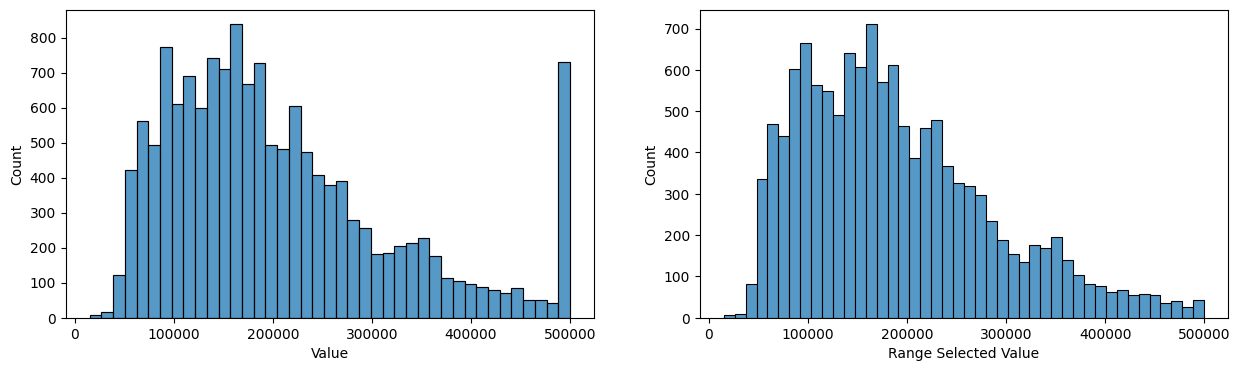

In [68]:
fig, axes = plt.subplots(1,2, figsize=(15, 4))
sns.histplot(df['median_house_value'], ax=axes[0])
sns.histplot(df_model['median_house_value'], ax=axes[1])
axes[0].set_xlabel('Value')
axes[1].set_xlabel('Range Selected Value');

In [96]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12548 entries, 0 to 14447
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           12548 non-null  float64
 1   latitude            12548 non-null  float64
 2   housing_median_age  12548 non-null  float64
 3   total_rooms         12548 non-null  float64
 4   population          12548 non-null  float64
 5   median_income       12548 non-null  float64
 6   ocean_proximity     12548 non-null  object 
 7   median_house_value  12548 non-null  float64
dtypes: float64(7), object(1)
memory usage: 882.3+ KB


##Split data

In [97]:
#Menentukan target
X = df_model.drop('median_house_value', axis=1)
y = df_model['median_house_value']

#Membagi data menjadi training (80%) dan testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

##Feature Engineering
- Mengisi missing value
- Melakukan encoding untuk kolom dengan tipe data object

In [98]:
print('Missing value di train')
print(X_train.isna().sum())
print()
print('Missing value di test')
print(X_test.isna().sum())

Missing value di train
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
median_income         0
ocean_proximity       0
dtype: int64

Missing value di test
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
population            0
median_income         0
ocean_proximity       0
dtype: int64


Sudah tidak ada data yang missing, maka akan dilanjutkan dengan mengubah kolom tipe object menjadi numerik

In [99]:
#Melihat apa saja unique value dari ocean_proximity
df_model['ocean_proximity'].unique()

array(['INLAND', 'NEAR BAY', '<1H OCEAN', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [100]:
#Melakukan ordinal encoding untuk ocean_proximity karena kedekatan dengan laut memiliki nilai yang lebih tinggi.
mapping_ocean = {
    'INLAND': 1,
    '<1H OCEAN': 2,
    'NEAR BAY': 3,
    'NEAR OCEAN': 4,
    'ISLAND': 5
}

# Terapkan mapping ke data Train dan Test
X_train['ocean_proximity'] = X_train['ocean_proximity'].map(mapping_ocean)
X_test['ocean_proximity'] = X_test['ocean_proximity'].map(mapping_ocean)

Saya menggunakan Ordinal Encoding karena rumah dengan lokasi lebih dekat dengan pantai cenderung lebih mahal dibandingkan dengan rumah yang lebih jauh, dengan kasus spesial adalah rumah yang berada di pulau, sehingga nilai pulau berada di nilai paling tinggi yaitu 5


##Training model

In [101]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Melatih model menggunakan data training
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

##Evaluation Metrics

In [102]:
y_pred = model.predict(X_test)

# Menghitung Metrik Sesuai Permintaan
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Menghitung MPSE (Mean Percentage Squared Error) - Custom calculation
mpse = np.mean(np.square((y_test - y_pred) / y_test))

# Menghitung MSLE (Mean Squared Logarithmic Error)
# Gunakan np.maximum(0, y_pred) untuk menghindari nilai negatif jika ada
msle = mean_squared_log_error(y_test, np.maximum(0, y_pred))

# Menampilkan Hasil Evaluasi
print("======= EVALUATION METRICS =======")
print(f"1. MAE       : {mae:.2f}")
print(f"2. MSE       : {mse:.2f}")
print(f"3. RMSE      : {rmse:.2f}")
print(f"4. MAPE      : {mape:.2%}")
print(f"5. MPSE      : {mpse:.4f}")
print(f"6. MSLE      : {msle:.4f}")
print(f"7. R-squared : {r2:.4f}")
print("==================================")

======= EVALUATION METRICS =======
1. MAE       : 31139.91
2. MSE       : 2171716941.38
3. RMSE      : 46601.68
4. MAPE      : 18.61%
5. MPSE      : 0.1646
6. MSLE      : 0.0591
7. R-squared : 0.7741


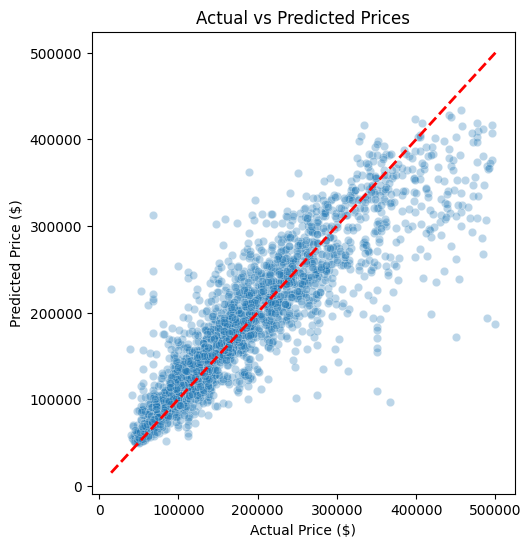

In [109]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')

plt.show()

####Analisis Evaluasi Metrik:
- MAE : Nilai 31.139,91 berarti model memiliki kesalahan rata-rata sebesar 31.139 dalam prediksinya. Misalkan Harga yang aslinya adalah 100.000 maka harga prediksinya adalah 69.000 - 131.139


- RMSE : Nilai 46.601,68 memiliki nilai yang lebih tinggi dari MAE. Ini berarti bahwa model masih melakukan beberapa kesalahan dengan error yang lebih besar di beberapa sektor. Pada grafik yang ada, model lebih banyak melakukan salah prediksi di actual price 300.000 ke atas


- MAPE : Nilai 18.80% berarti bahwa model memiliki tingkat kesalahan sebesar 18.75% dari harga rumah. Misalkan harga aslinya adalah 200.000 maka harga prediksinya adalah 162.500 - 237.500


- MSLE : Dengan nilai yang relatif kecil 0.059 maka dapat dikatakan bahwa model memiliki prediksi yang cukup stabil antara rumah dengan harga yang lebih murah dan rumah dengan harga yang lebih mahal


- R-Squared : Nilai 0.7741 berarti bahwa model sudah dapat memahami pola data sebesar 77.41%

####Conclusion

- Performa model (MAPE) memiliki niali 18.80%, ini berarti model memiliki tingkat kesalah 18.80% yang menjadikan model ini cukup baik dalam skala industri.


- Nilai MSLE juga berarti model ini tidak terlalu memiliki bias terhadap variasi harga rumah yang lebih murah ataupun lebih mahal dan prediksinya relatif stabil.


- Nilai R-Squared 0.7741 memiliki nilai yang cukup baik karena telah memahami pola data sebesar 77.41%

####Batasan Model

- Nilai RMSE lebiih tinggi dibanding dengan MAE menandakan terdapat lebih besar ruang kesalahan pada outlier.

- Dataset memiliki keterbatasan di harga 500.000, sehingga harga rumah di atas 500.000 tidak akan diprediksi dengan baik.

####Recomendations
- Untuk mendapatkan hasil yang lebih baik, range harga rumah sebaiknya ditingkatkan lagi, dan tidak terbatas pada harga 500.000
- Perbanyak data pada dataset, untuk hasil yang lebih baik.
- Karena pendapatan memiliki korelasi yang sangat tinggi untuk memprediksi harga rumah, maka fitur tersebut merupakan hal terpenting yang harus dilihat pada data
- Untuk harga rumah pada kisaran 500.000 dibutuhkan manusia untuk memverifikasi ulang harganya, karena data outlier tidak dapat dibaca dengan baik dengan model.

In [111]:
import pickle

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

filename = 'Model_California_RF.sav'

# Menyimpan model menggunakan pickle.dump
pickle.dump(model_rf, open(filename, 'wb'))
print(f"Model berhasil disimpan sebagai: {filename}")

# Load model yang telah disimpan
loaded_model = pickle.load(open(filename, 'rb'))

# Verifikasi hasil: Menghitung RMSE menggunakan model yang dimuat
rmse_check = np.sqrt(mean_squared_error(y_test, loaded_model.predict(X_test)))

print(f"RMSE dari model yang dimuat kembali: {rmse_check:.2f}")

Model berhasil disimpan sebagai: Model_California_RF.sav
RMSE dari model yang dimuat kembali: 46601.68


In [112]:
#Mengkompres model
import joblib

filename_compressed = 'Model_California_RF_compressed.joblib'
joblib.dump(model_rf, filename_compressed, compress=3)

['Model_California_RF_compressed.joblib']